In [3]:
!pip install pandas numpy matplotlib seaborn tsfresh scikit-learn deap xgboost lightgbm

In [61]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [62]:
data_path = "data"
os.listdir(data_path)

['RUL_FD001.txt', 'test_FD001.txt', 'train_FD001.txt']

In [63]:
train_df = pd.read_csv(
    "data/train_FD001.txt",
    sep=r"\s+",
    header=None
)

In [64]:
train_df = train_df.iloc[:, :26]
train_df.shape

(20631, 26)

In [65]:
column_names = (
    ['engine_id', 'cycle'] +
    [f'op_setting_{i}' for i in range(1, 4)] +
    [f'sensor_{i}' for i in range(1, 22)]
)

In [66]:
train_df.columns = column_names
train_df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [67]:
test_df = pd.read_csv(
    "data/test_FD001.txt",
    sep=r"\s+",
    header=None
)

test_df = test_df.iloc[:, :26]
test_df.columns = column_names
test_df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [68]:
rul_df = pd.read_csv(
    "data/RUL_FD001.txt",
    sep=r"\s+",
    header=None
)

rul_df = rul_df.iloc[:, :1]
rul_df.columns = ['RUL']

rul_df.head()

,RUL
0,112
1,98
2,69
3,82
4,91


In [69]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   engine_id     20631 non-null  int64  
 1   cycle         20631 non-null  int64  
 2   op_setting_1  20631 non-null  float64
 3   op_setting_2  20631 non-null  float64
 4   op_setting_3  20631 non-null  float64
 5   sensor_1      20631 non-null  float64
 6   sensor_2      20631 non-null  float64
 7   sensor_3      20631 non-null  float64
 8   sensor_4      20631 non-null  float64
 9   sensor_5      20631 non-null  float64
 10  sensor_6      20631 non-null  float64
 11  sensor_7      20631 non-null  float64
 12  sensor_8      20631 non-null  float64
 13  sensor_9      20631 non-null  float64
 14  sensor_10     20631 non-null  float64
 15  sensor_11     20631 non-null  float64
 16  sensor_12     20631 non-null  float64
 17  sensor_13     20631 non-null  float64
 18  sensor_14     20631 non-nu

In [70]:
train_df.describe()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


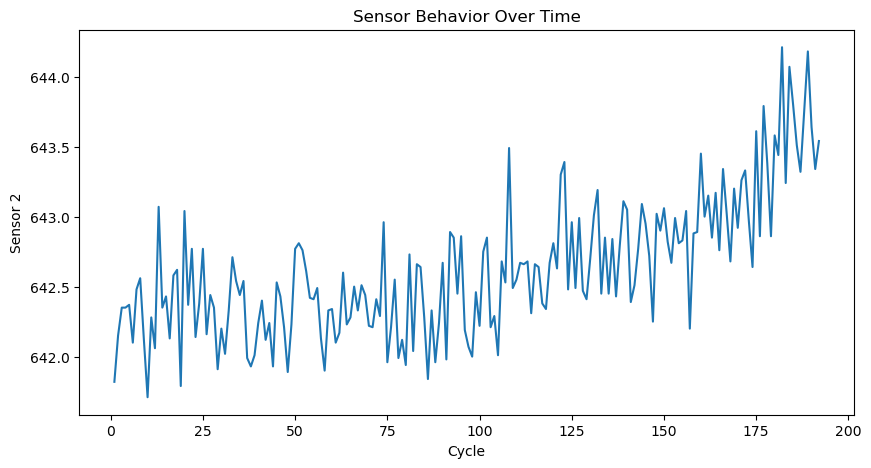

In [71]:
engine_example = train_df[train_df['engine_id'] == 1]

plt.figure(figsize=(10,5))
plt.plot(engine_example['cycle'], engine_example['sensor_2'])
plt.xlabel("Cycle")
plt.ylabel("Sensor 2")
plt.title("Sensor Behavior Over Time")
plt.show()

In [72]:
max_cycle_df = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycle_df.columns = ['engine_id', 'max_cycle']
max_cycle_df.head()

,engine_id,max_cycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


In [73]:
train_df = train_df.merge(max_cycle_df, on='engine_id', how='left')
train_df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192


In [74]:
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
train_df[['engine_id', 'cycle', 'max_cycle', 'RUL']].head(10)

,engine_id,cycle,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187
5,1,6,192,186
6,1,7,192,185
7,1,8,192,184
8,1,9,192,183
9,1,10,192,182


In [76]:
train_df.drop(columns=['max_cycle'], inplace=True)
train_df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [77]:
train_df[['engine_id', 'cycle', 'RUL']].sample(10)

,engine_id,cycle,RUL
15535,78,13,218
20397,99,152,33
5189,26,80,119
11963,61,22,163
1188,6,73,115
2505,12,130,40
2833,14,125,55
9603,49,108,107
1237,6,122,66
8075,42,34,162


In [78]:
train_df[train_df['engine_id'] == 1][['cycle', 'RUL']].tail(10)

,cycle,RUL
182,183,9
183,184,8
184,185,7
185,186,6
186,187,5
187,188,4
188,189,3
189,190,2
190,191,1
191,192,0


In [79]:
train_df.isnull().sum().sort_values(ascending=False).head(10)

engine_id    0
sensor_10    0
sensor_21    0
sensor_20    0
sensor_19    0
sensor_18    0
sensor_17    0
sensor_16    0
sensor_15    0
sensor_14    0
dtype: int64

In [80]:
train_df[train_df['engine_id'] == 1][['cycle', 'RUL']].tail(10)

,cycle,RUL
182,183,9
183,184,8
184,185,7
185,186,6
186,187,5
187,188,4
188,189,3
189,190,2
190,191,1
191,192,0


In [81]:
!pip install tsfresh

In [82]:
from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import impute

In [83]:
feature_df = train_df.drop(columns=['RUL'])
feature_df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [84]:
sensor_columns = [col for col in feature_df.columns if 'sensor' in col]
sensor_columns[:5]

['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5']

In [85]:
tsfresh_input = train_df[['engine_id', 'cycle'] + sensor_columns]
tsfresh_input.head()

,engine_id,cycle,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [86]:
extracted_features = extract_features(
    tsfresh_input,
    column_id="engine_id",
    column_sort="cycle"
)

Feature Extraction: 100%|██████████████████████████████████████████████████████████████| 20/20 [03:08<00:00,  9.43s/it]


In [87]:
impute(extracted_features)
extracted_features.head()

C:\Users\ragad\anaconda3\Lib\site-packages\tsfresh\utilities\dataframe_functions.py:198: RuntimeWarning: The columns ['sensor_1__autocorrelation__lag_0' 'sensor_1__autocorrelation__lag_1'
 'sensor_1__autocorrelation__lag_2' 'sensor_1__autocorrelation__lag_3'
 'sensor_1__autocorrelation__lag_4' 'sensor_1__autocorrelation__lag_5'
 'sensor_1__autocorrelation__lag_6' 'sensor_1__autocorrelation__lag_7'
 'sensor_1__autocorrelation__lag_8' 'sensor_1__autocorrelation__lag_9'
 'sensor_1__partial_autocorrelation__lag_2'
 'sensor_1__partial_autocorrelation__lag_3'
 'sensor_1__partial_autocorrelation__lag_4'
 'sensor_1__partial_autocorrelation__lag_5'
 'sensor_1__partial_autocorrelation__lag_6'
 'sensor_1__partial_autocorrelation__lag_7'
 'sensor_1__partial_autocorrelation__lag_8'
 'sensor_1__partial_autocorrelation__lag_9'
 'sensor_1__fft_aggregated__aggtype_"skew"'
 'sensor_1__fft_aggregated__aggtype_"kurtosis"'
 'sensor_1__friedrich_coefficients__coeff_0__m_3__r_30'
 'sensor_1__friedrich_coeffi

,sensor_1__variance_larger_than_standard_deviation,sensor_1__has_duplicate_max,sensor_1__has_duplicate_min,sensor_1__has_duplicate,sensor_1__sum_values,sensor_1__abs_energy,sensor_1__mean_abs_change,sensor_1__mean_change,sensor_1__mean_second_derivative_central,sensor_1__median,...,sensor_21__fourier_entropy__bins_5,sensor_21__fourier_entropy__bins_10,sensor_21__fourier_entropy__bins_100,sensor_21__permutation_entropy__dimension_3__tau_1,sensor_21__permutation_entropy__dimension_4__tau_1,sensor_21__permutation_entropy__dimension_5__tau_1,sensor_21__permutation_entropy__dimension_6__tau_1,sensor_21__permutation_entropy__dimension_7__tau_1,sensor_21__query_similarity_count__query_None__threshold_0.0,sensor_21__mean_n_absolute_max__number_of_maxima_7
1,0.0,1.0,1.0,1.0,99584.64,5.165157e+07,0.0,0.0,0.0,518.67,...,0.114728,0.214731,2.078694,1.786110,3.123432,4.449288,5.065217,5.203387,0.0,23.479800
2,0.0,1.0,1.0,1.0,148858.29,7.720833e+07,0.0,0.0,0.0,518.67,...,0.125256,0.432434,2.439350,1.784838,3.149914,4.598803,5.424955,5.613688,0.0,23.536643
3,0.0,1.0,1.0,1.0,92841.93,4.815432e+07,0.0,0.0,0.0,518.67,...,0.121969,0.267352,1.697399,1.784083,3.136497,4.438378,4.993697,5.129252,0.0,23.484414
4,0.0,1.0,1.0,1.0,98028.63,5.084451e+07,0.0,0.0,0.0,518.67,...,0.116701,0.403762,2.376414,1.776005,3.089530,4.301761,5.023737,5.186760,0.0,23.458643
5,0.0,1.0,1.0,1.0,139522.23,7.236600e+07,0.0,0.0,0.0,518.67,...,0.090729,0.090729,1.877006,1.791611,3.157075,4.570465,5.359001,5.510193,0.0,23.524814


In [88]:
y = train_df.groupby('engine_id')['RUL'].max()
y.head()

engine_id
1    191
2    286
3    178
4    188
5    268
Name: RUL, dtype: int64

In [90]:
extracted_features.shape

(100, 16443)

In [91]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

In [92]:
selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X)

X_var = pd.DataFrame(
    X_var,
    columns=X.columns[selector.get_support()]
)

X_var.shape

C:\Users\ragad\anaconda3\Lib\site-packages\sklearn\feature_selection\_variance_threshold.py:111: RuntimeWarning: Degrees of freedom <= 0 for slice.
  self.variances_ = np.nanvar(X, axis=0)


(100, 9017)

In [93]:
corr_matrix = X_var.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

X_corr = X_var.drop(columns=to_drop)

X_corr.shape

(100, 7081)

In [98]:
X_corr.isnull().sum().sum()

42399

In [99]:
X_corr = X_corr.dropna(axis=1, how='all')
X_corr.shape

(100, 7081)

In [100]:
X_corr = X_corr.fillna(X_corr.median())

In [101]:
X_corr.isnull().sum().sum()

0

In [102]:
mi_scores = mutual_info_regression(X_corr, y)

mi_scores = pd.Series(mi_scores, index=X_corr.columns)
mi_scores = mi_scores.sort_values(ascending=False)

mi_scores.head(10)

op_setting1__length                                                       3.211211
sensor_16__longest_strike_below_mean                                      2.181264
sensor_10__longest_strike_below_mean                                      1.863328
sensor_10__agg_linear_trend__attr_"rvalue"__chunk_len_10__f_agg_"mean"    1.663218
sensor_16__agg_linear_trend__attr_"rvalue"__chunk_len_10__f_agg_"mean"    1.315915
sensor_5__longest_strike_below_mean                                       1.149631
sensor_6__count_above_mean                                                1.128111
sensor_9__count_below_mean                                                0.849927
sensor_18__fft_coefficient__attr_"angle"__coeff_87                        0.849891
sensor_11__number_peaks__n_5                                              0.822571
dtype: float64

In [103]:
top_features = mi_scores.head(50).index
X_selected = X_corr[top_features]

X_selected.shape

(100, 50)

In [104]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

In [105]:
impute(extracted_features)

,sensor_1__variance_larger_than_standard_deviation,sensor_1__has_duplicate_max,sensor_1__has_duplicate_min,sensor_1__has_duplicate,sensor_1__sum_values,sensor_1__abs_energy,sensor_1__mean_abs_change,sensor_1__mean_change,sensor_1__mean_second_derivative_central,sensor_1__median,...,sensor_21__fourier_entropy__bins_5,sensor_21__fourier_entropy__bins_10,sensor_21__fourier_entropy__bins_100,sensor_21__permutation_entropy__dimension_3__tau_1,sensor_21__permutation_entropy__dimension_4__tau_1,sensor_21__permutation_entropy__dimension_5__tau_1,sensor_21__permutation_entropy__dimension_6__tau_1,sensor_21__permutation_entropy__dimension_7__tau_1,sensor_21__query_similarity_count__query_None__threshold_0.0,sensor_21__mean_n_absolute_max__number_of_maxima_7
1,0.0,1.0,1.0,1.0,99584.64,5.165157e+07,0.0,0.0,0.0,518.67,...,0.114728,0.214731,2.078694,1.786110,3.123432,4.449288,5.065217,5.203387,0.0,23.479800
2,0.0,1.0,1.0,1.0,148858.29,7.720833e+07,0.0,0.0,0.0,518.67,...,0.125256,0.432434,2.439350,1.784838,3.149914,4.598803,5.424955,5.613688,0.0,23.536643
3,0.0,1.0,1.0,1.0,92841.93,4.815432e+07,0.0,0.0,0.0,518.67,...,0.121969,0.267352,1.697399,1.784083,3.136497,4.438378,4.993697,5.129252,0.0,23.484414
4,0.0,1.0,1.0,1.0,98028.63,5.084451e+07,0.0,0.0,0.0,518.67,...,0.116701,0.403762,2.376414,1.776005,3.089530,4.301761,5.023737,5.186760,0.0,23.458643
5,0.0,1.0,1.0,1.0,139522.23,7.236600e+07,0.0,0.0,0.0,518.67,...,0.090729,0.090729,1.877006,1.791611,3.157075,4.570465,5.359001,5.510193,0.0,23.524814
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.0,1.0,1.0,1.0,174273.12,9.039024e+07,0.0,0.0,0.0,518.67,...,0.342277,0.727480,2.735621,1.781470,3.144949,4.615812,5.537708,5.761285,0.0,23.497129
97,0.0,1.0,1.0,1.0,104771.34,5.434175e+07,0.0,0.0,0.0,518.67,...,0.110100,0.206217,2.044656,1.789259,3.145494,4.522279,5.130114,5.242750,0.0,23.486629
98,0.0,1.0,1.0,1.0,80912.52,4.196690e+07,0.0,0.0,0.0,518.67,...,0.067887,0.267600,2.323477,1.789810,3.054709,4.281450,4.879568,5.001393,0.0,23.515629
99,0.0,1.0,1.0,1.0,95953.95,4.976844e+07,0.0,0.0,0.0,518.67,...,0.118748,0.118748,1.888180,1.789807,3.146135,4.482629,5.008118,5.156407,0.0,23.474543


In [108]:
!pip install deap

In [109]:
import random
from deap import base, creator, tools, algorithms
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

In [110]:
X_ga = pd.DataFrame(X_scaled, columns=X_selected.columns, index=X_selected.index)
X_ga.head()

,op_setting1__length,sensor_16__longest_strike_below_mean,sensor_10__longest_strike_below_mean,"sensor_10__agg_linear_trend__attr_""rvalue""__chunk_len_10__f_agg_""mean""","sensor_16__agg_linear_trend__attr_""rvalue""__chunk_len_10__f_agg_""mean""",sensor_5__longest_strike_below_mean,sensor_6__count_above_mean,sensor_9__count_below_mean,"sensor_18__fft_coefficient__attr_""angle""__coeff_87",sensor_11__number_peaks__n_5,...,"sensor_5__fft_coefficient__attr_""angle""__coeff_7","op_setting3__fft_coefficient__attr_""angle""__coeff_98","sensor_5__fft_coefficient__attr_""angle""__coeff_88","sensor_18__fft_coefficient__attr_""angle""__coeff_81",sensor_2__number_cwt_peaks__n_1,"sensor_5__fft_coefficient__attr_""angle""__coeff_73","sensor_10__fft_coefficient__attr_""angle""__coeff_68",sensor_14__number_cwt_peaks__n_1,sensor_15__fourier_entropy__bins_5,sensor_15__approximate_entropy__m_2__r_0.1
0,-0.310342,0.254399,0.457037,-0.730564,0.062136,0.810368,-1.241644,-0.714901,0.289691,-0.402477,...,-0.261636,0.057998,-0.155311,-0.485172,0.627090,-0.009124,0.013793,0.813166,-0.318112,-0.146775
1,1.749929,-1.823210,-1.474957,1.518232,0.789101,-0.908296,1.256934,1.910684,-1.427730,1.198285,...,1.291010,3.030525,0.231161,0.310615,0.627090,-0.009124,0.013793,0.813166,-0.506653,2.687578
2,-0.592274,0.113727,0.326225,-0.848386,0.536130,-0.908296,0.389890,0.055651,0.289691,-0.631158,...,1.557177,0.057998,-0.155311,-0.485172,-0.854225,-0.009124,0.013793,-0.256789,-0.261228,-0.018675
3,-0.375403,-1.823210,0.426850,-0.787415,0.569741,-0.908296,0.511090,0.341041,-1.741169,-0.402477,...,-0.261636,0.057998,-0.410469,1.739415,-0.360453,-0.101831,0.013793,0.813166,-0.302619,0.781362
4,1.359562,1.087607,1.231847,1.294367,0.757069,-0.908296,1.098442,1.710912,0.289691,0.740924,...,1.557177,0.254433,-0.155311,-0.485172,0.462500,2.181083,0.013793,1.704796,-0.506653,1.726564


In [111]:
if hasattr(creator, "FitnessMin"):
    del creator.FitnessMin
if hasattr(creator, "Individual"):
    del creator.Individual

In [112]:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

In [113]:
toolbox = base.Toolbox()

n_features = X_ga.shape[1]

toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=n_features)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

In [114]:
def eval_features(individual):
    selected_idx = [i for i, bit in enumerate(individual) if bit == 1]
    
    if len(selected_idx) == 0:
        return (9999,)
    
    X_subset = X_ga.iloc[:, selected_idx]
    
    model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
    
    scores = cross_val_score(
        model,
        X_subset,
        y,
        cv=3,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    
    rmse = -scores.mean()
    
    penalty = 0.01 * len(selected_idx)
    
    return (rmse + penalty,)

In [115]:
toolbox.register("evaluate", eval_features)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

In [116]:
population = toolbox.population(n=20)

In [117]:
result, logbook = algorithms.eaSimple(
    population,
    toolbox,
    cxpb=0.5,
    mutpb=0.2,
    ngen=10,
    verbose=True
)

gen	nevals
0  	20    
1  	12    
2  	18    
3  	11    
4  	14    
5  	8     
6  	13    
7  	11    
8  	8     
9  	7     
10 	5     


In [118]:
best_individual = tools.selBest(population, k=1)[0]
selected_idx = [i for i, bit in enumerate(best_individual) if bit == 1]
selected_ga_features = X_ga.columns[selected_idx]

len(selected_ga_features), list(selected_ga_features[:10])

(23,
 ['op_setting1__length',
  'sensor_10__longest_strike_below_mean',
  'sensor_10__agg_linear_trend__attr_"rvalue"__chunk_len_10__f_agg_"mean"',
  'sensor_5__longest_strike_below_mean',
  'sensor_6__count_above_mean',
  'sensor_11__number_peaks__n_5',
  'sensor_10__agg_linear_trend__attr_"rvalue"__chunk_len_50__f_agg_"mean"',
  'sensor_9__fourier_entropy__bins_2',
  'sensor_17__fourier_entropy__bins_3',
  'sensor_3__number_cwt_peaks__n_1'])

In [119]:
X_final = X_ga[selected_ga_features]
X_final.shape

(100, 23)

In [120]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_valid.shape

((80, 23), (20, 23))

In [121]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [122]:
y_pred = rf_model.predict(X_valid)
y_pred[:10]

array([263.565, 267.505, 207.515, 263.645, 153.73 , 186.68 , 168.39 ,
       230.97 , 228.775, 192.16 ])

In [123]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
mae = mean_absolute_error(y_valid, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 5.105485040620528
MAE: 3.7429999999999963


In [124]:
print("Number of GA-selected features:", X_final.shape[1])

Number of GA-selected features: 23


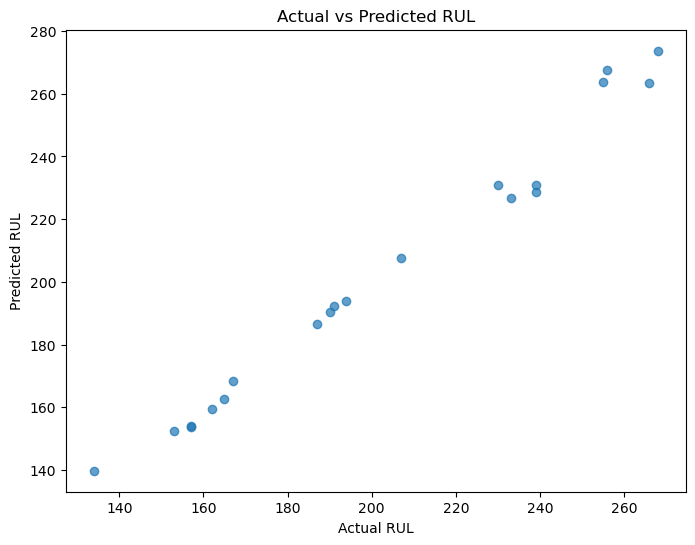

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_valid, y_pred, alpha=0.7)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")
plt.show()

In [126]:
import time

start_time = time.time()

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_valid)

end_time = time.time()

print("Training + prediction runtime (seconds):", end_time - start_time)

Training + prediction runtime (seconds): 0.43927597999572754


In [128]:

print("Feature matrix after tsfresh:", X.shape)
print("After filter selection:", X_selected.shape)
print("After GA selection:", X_final.shape)
print("RMSE:", rmse)
print("MAE:", mae)

Feature matrix after tsfresh: (100, 18792)
After filter selection: (100, 50)
After GA selection: (100, 23)
RMSE: 5.105485040620528
MAE: 3.7429999999999963


In [129]:
max_cycle_test = test_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycle_test.columns = ['engine_id', 'max_cycle']

max_cycle_test.head()

,engine_id,max_cycle
0,1,31
1,2,49
2,3,126
3,4,106
4,5,98


In [130]:
rul_df['engine_id'] = rul_df.index + 1

test_rul = max_cycle_test.merge(rul_df, on='engine_id')
test_rul.head()

,engine_id,max_cycle,RUL
0,1,31,112
1,2,49,98
2,3,126,69
3,4,106,82
4,5,98,91


In [131]:
test_rul['final_cycle'] = test_rul['max_cycle'] + test_rul['RUL']
test_rul.head()

,engine_id,max_cycle,RUL,final_cycle
0,1,31,112,143
1,2,49,98,147
2,3,126,69,195
3,4,106,82,188
4,5,98,91,189


In [132]:
test_df = test_df.merge(
    test_rul[['engine_id', 'final_cycle']],
    on='engine_id',
    how='left'
)

test_df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,final_cycle
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,143
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,143
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,143
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,143
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,143


In [133]:
test_df['RUL'] = test_df['final_cycle'] - test_df['cycle']
test_df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,final_cycle,RUL
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,143,142
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,143,141
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,143,140
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,143,139
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,143,138


In [137]:
test_df.columns

Index(['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'RUL'],
      dtype='object')

In [138]:
test_df = test_df.merge(
    test_rul[['engine_id', 'final_cycle']],
    on='engine_id',
    how='left'
)

In [139]:
test_df.columns

Index(['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'RUL',
       'final_cycle'],
      dtype='object')

In [140]:
test_df['RUL'] = test_df['final_cycle'] - test_df['cycle']

In [141]:
test_df.drop(columns=['final_cycle'], inplace=True)

In [143]:
tsfresh_test_input = test_df[['engine_id', 'cycle'] + sensor_columns]

In [173]:
import time

start = time.time()


In [145]:
test_features = extract_features(
    tsfresh_test_input,
    column_id="engine_id",
    column_sort="cycle"
)

Feature Extraction: 100%|██████████████████████████████████████████████████████████████| 20/20 [01:50<00:00,  5.52s/it]


In [174]:
end = time.time()

print("Feature extraction runtime:", end - start, "seconds")

Feature extraction runtime: 6.990995407104492 seconds


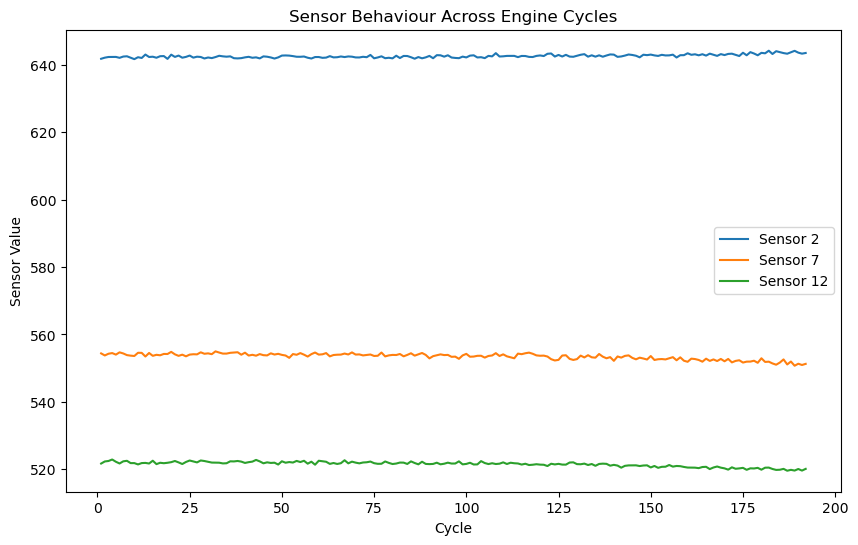

In [176]:
engine_example = train_df[train_df['engine_id'] == 1]

plt.figure(figsize=(10,6))

plt.plot(engine_example['cycle'], engine_example['sensor_2'], label='Sensor 2')
plt.plot(engine_example['cycle'], engine_example['sensor_7'], label='Sensor 7')
plt.plot(engine_example['cycle'], engine_example['sensor_12'], label='Sensor 12')

plt.xlabel("Cycle")
plt.ylabel("Sensor Value")
plt.title("Sensor Behaviour Across Engine Cycles")
plt.legend()
plt.show()

In [146]:
impute(test_features)

C:\Users\ragad\anaconda3\Lib\site-packages\tsfresh\utilities\dataframe_functions.py:198: RuntimeWarning: The columns ['sensor_1__autocorrelation__lag_0' 'sensor_1__autocorrelation__lag_1'
 'sensor_1__autocorrelation__lag_2' 'sensor_1__autocorrelation__lag_3'
 'sensor_1__autocorrelation__lag_4' 'sensor_1__autocorrelation__lag_5'
 'sensor_1__autocorrelation__lag_6' 'sensor_1__autocorrelation__lag_7'
 'sensor_1__autocorrelation__lag_8' 'sensor_1__autocorrelation__lag_9'
 'sensor_1__partial_autocorrelation__lag_2'
 'sensor_1__partial_autocorrelation__lag_3'
 'sensor_1__partial_autocorrelation__lag_4'
 'sensor_1__partial_autocorrelation__lag_5'
 'sensor_1__partial_autocorrelation__lag_6'
 'sensor_1__partial_autocorrelation__lag_7'
 'sensor_1__partial_autocorrelation__lag_8'
 'sensor_1__partial_autocorrelation__lag_9'
 'sensor_1__fft_aggregated__aggtype_"skew"'
 'sensor_1__fft_aggregated__aggtype_"kurtosis"'
 'sensor_1__friedrich_coefficients__coeff_0__m_3__r_30'
 'sensor_1__friedrich_coeffi

,sensor_1__variance_larger_than_standard_deviation,sensor_1__has_duplicate_max,sensor_1__has_duplicate_min,sensor_1__has_duplicate,sensor_1__sum_values,sensor_1__abs_energy,sensor_1__mean_abs_change,sensor_1__mean_change,sensor_1__mean_second_derivative_central,sensor_1__median,...,sensor_21__fourier_entropy__bins_5,sensor_21__fourier_entropy__bins_10,sensor_21__fourier_entropy__bins_100,sensor_21__permutation_entropy__dimension_3__tau_1,sensor_21__permutation_entropy__dimension_4__tau_1,sensor_21__permutation_entropy__dimension_5__tau_1,sensor_21__permutation_entropy__dimension_6__tau_1,sensor_21__permutation_entropy__dimension_7__tau_1,sensor_21__query_similarity_count__query_None__threshold_0.0,sensor_21__mean_n_absolute_max__number_of_maxima_7
1,0.0,1.0,1.0,1.0,16078.77,8.339576e+06,0.0,0.0,0.0,518.67,...,1.422630,1.803719,2.685945,1.717234,2.601682,3.090460,3.258097,3.218876,0.0,23.428057
2,0.0,1.0,1.0,1.0,25414.83,1.318191e+07,0.0,0.0,0.0,518.67,...,1.105087,1.679818,2.976139,1.777175,2.873544,3.548582,3.752683,3.761200,0.0,23.422414
3,0.0,1.0,1.0,1.0,65352.42,3.389634e+07,0.0,0.0,0.0,518.67,...,1.068766,1.683373,3.429085,1.791498,3.018674,4.214423,4.699810,4.775939,0.0,23.397714
4,0.0,1.0,1.0,1.0,54979.02,2.851597e+07,0.0,0.0,0.0,518.67,...,0.960071,1.566680,3.201054,1.783568,3.021669,4.110043,4.560218,4.605170,0.0,23.403629
5,0.0,1.0,1.0,1.0,50829.66,2.636382e+07,0.0,0.0,0.0,518.67,...,1.486768,2.121604,3.492466,1.785214,3.123356,4.146767,4.383536,4.491652,0.0,23.405100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.0,1.0,1.0,1.0,50310.99,2.609480e+07,0.0,0.0,0.0,518.67,...,1.168446,1.737720,3.276337,1.774029,3.014755,4.051650,4.416310,4.480391,0.0,23.509871
97,0.0,1.0,1.0,1.0,69501.78,3.604849e+07,0.0,0.0,0.0,518.67,...,1.152471,1.768560,3.429261,1.784840,3.124967,4.352850,4.784587,4.852030,0.0,23.497843
98,0.0,1.0,1.0,1.0,62759.07,3.255125e+07,0.0,0.0,0.0,518.67,...,1.071085,1.702549,3.448809,1.756316,3.052683,4.060711,4.646033,4.744932,0.0,23.443471
99,0.0,1.0,1.0,1.0,50310.99,2.609480e+07,0.0,0.0,0.0,518.67,...,1.189241,1.793766,3.269768,1.767131,3.068298,4.072183,4.446446,4.480391,0.0,23.515286


In [149]:
missing_features = [col for col in selected_ga_features if col not in test_features.columns]
len(missing_features), missing_features[:10]


(2,
 ['op_setting1__length',
  'op_setting3__fft_coefficient__attr_"angle"__coeff_80'])

In [150]:
for col in selected_ga_features:
    if col not in test_features.columns:
        test_features[col] = 0

In [151]:
X_test = test_features.reindex(columns=selected_ga_features, fill_value=0)
X_test.shape

(100, 23)

In [152]:
X_test.isnull().sum().sum()

0

In [153]:
X_test = X_test.fillna(0)

In [155]:
test_predictions = rf_model.predict(X_test)
test_predictions[:10]

array([214.04 , 221.53 , 225.975, 226.815, 225.975, 234.66 , 235.405,
       222.28 , 223.775, 234.325])

In [157]:
X_test = test_features[selected_ga_features]

In [158]:
X_test = test_features.reindex(columns=selected_ga_features, fill_value=0)

In [159]:
missing_features = [col for col in selected_ga_features if col not in test_features.columns]
len(missing_features), missing_features[:10]

(0, [])

In [163]:
X_test = test_features.reindex(columns=selected_ga_features, fill_value=0)
X_test = X_test.fillna(0)
X_test.shape

(100, 23)

In [164]:
y_test = test_df.groupby('engine_id')['RUL'].max()
y_test.head()

engine_id
1    142
2    146
3    194
4    187
5    188
Name: RUL, dtype: int64

In [165]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse_test = np.sqrt(mean_squared_error(y_test, test_predictions))
mae_test = mean_absolute_error(y_test, test_predictions)

print("Test RMSE:", rmse_test)
print("Test MAE:", mae_test)

Test RMSE: 47.66197199287918
Test MAE: 40.79814999999999


In [166]:
print("Original tsfresh features:", X.shape[1])
print("After filter selection:", X_selected.shape[1])
print("After GA selection:", X_final.shape[1])

Original tsfresh features: 18792
After filter selection: 50
After GA selection: 23


In [167]:
import time

start_time = time.time()
test_predictions = rf_model.predict(X_test)
end_time = time.time()

print("Test prediction runtime (seconds):", end_time - start_time)

Test prediction runtime (seconds): 0.11328530311584473


In [168]:
print("Validation RMSE:", rmse)
print("Validation MAE:", mae)
print("Test RMSE:", rmse_test)
print("Test MAE:", mae_test)
print("Original tsfresh features:", X.shape[1])
print("After filter selection:", X_selected.shape[1])
print("After GA selection:", X_final.shape[1])

Validation RMSE: 5.105485040620528
Validation MAE: 3.7429999999999963
Test RMSE: 47.66197199287918
Test MAE: 40.79814999999999
Original tsfresh features: 18792
After filter selection: 50
After GA selection: 23
